# Trend Signal

The EDA showed a weak but non-zero correlation between Google search interest and future stock returns. This notebook turns that into an actual signal — something that tilts portfolio weights based on what people are currently searching.

The idea: if "quiet luxury" is trending unusually high relative to its recent baseline, overweight LVMH. If "zara haul" is spiking, tilt toward Inditex. The signal adjusts the max-Sharpe weights rather than replacing them.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}

SIGNAL_MAP = {
    'quiet luxury' : 'LVMH',
    'zara haul'    : 'Inditex',
    'streetwear'   : 'H&M',
}

prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
trends = pd.read_csv('data/trends.csv', index_col=0, parse_dates=True)


prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

if trends.empty:
    raise ValueError('trends.csv is empty — re-run 01_data_collection.ipynb.')

# monthly or weekly data
freq_days  = (trends.index[1] - trends.index[0]).days
IS_MONTHLY = freq_days > 14
FREQ_LABEL = 'months' if IS_MONTHLY else 'weeks'
RESAMPLE   = 'ME'     if IS_MONTHLY else 'W'
WINDOW     = 6        if IS_MONTHLY else 12
ROLL_WIN   = 12       if IS_MONTHLY else 26

print(f'Trends frequency: {FREQ_LABEL}  ({freq_days} days between observations)')
print(f'Rolling window: {WINDOW} {FREQ_LABEL}')
print(f'Prices shape: {prices.shape}')
print(f'Trends shape: {trends.shape}')

# only signal columns
SIGNAL_MAP = {k: v for k, v in SIGNAL_MAP.items() if k in trends.columns}
print(f'Active signals: {SIGNAL_MAP}')

Trends frequency: months  (31 days between observations)
Rolling window: 6 months
Prices shape: (1550, 4)
Trends shape: (72, 3)
Active signals: {'quiet luxury': 'LVMH', 'zara haul': 'Inditex', 'streetwear': 'H&M'}


## 1. Signal Construction

Raw Trends values (0 - 100 ) aren't directly useful because they're scaled to the peak within the full period, not to what's "normal" recently. A score of 40 means something different if the recent baseline is 20 vs 38.

I'm using a rolling z-score. How many standard deviations above or below the recent baseline is this period's search interest?

$$z_t = \frac{x_t - \mu_{t-W:t}}{\sigma_{t-W:t}}$$

Columns that are near-constant over the whole window (std ≈ 0) get dropped — they carry no signal.

In [ ]:
def rolling_zscore(series, window):
    roll_mean = series.rolling(window, min_periods=window).mean()
    roll_std  = series.rolling(window, min_periods=window).std()
    roll_std  = roll_std.where(roll_std > 1e-6, np.nan)   # treat near-zero std as NaN
    return (series - roll_mean) / roll_std


raw_signals = pd.DataFrame(index=trends.index)
for col in trends.columns:
    raw_signals[col] = rolling_zscore(trends[col], WINDOW)

# drop columns that are NaN
usable = raw_signals.columns[raw_signals.notna().any()]
signals = raw_signals[usable].dropna(how='all')

dropped = set(trends.columns) - set(usable)
if dropped:
    print(f'[info] Dropped near-constant keywords (no usable signal): {dropped}')

    SIGNAL_MAP = {k: v for k, v in SIGNAL_MAP.items() if k in usable}

if signals.empty:
    raise ValueError('no signal data')


signals.describe().round(3)
print(f'Signal shape: {signals.shape}')
print(f'Date range: {signals.index[0].date()} → {signals.index[-1].date()}')
print(f'Active pairs: {SIGNAL_MAP}')

Signal shape: (67, 3)
Date range: 2020-06-01 → 2025-12-01
Active pairs: {'quiet luxury': 'LVMH', 'zara haul': 'Inditex', 'streetwear': 'H&M'}


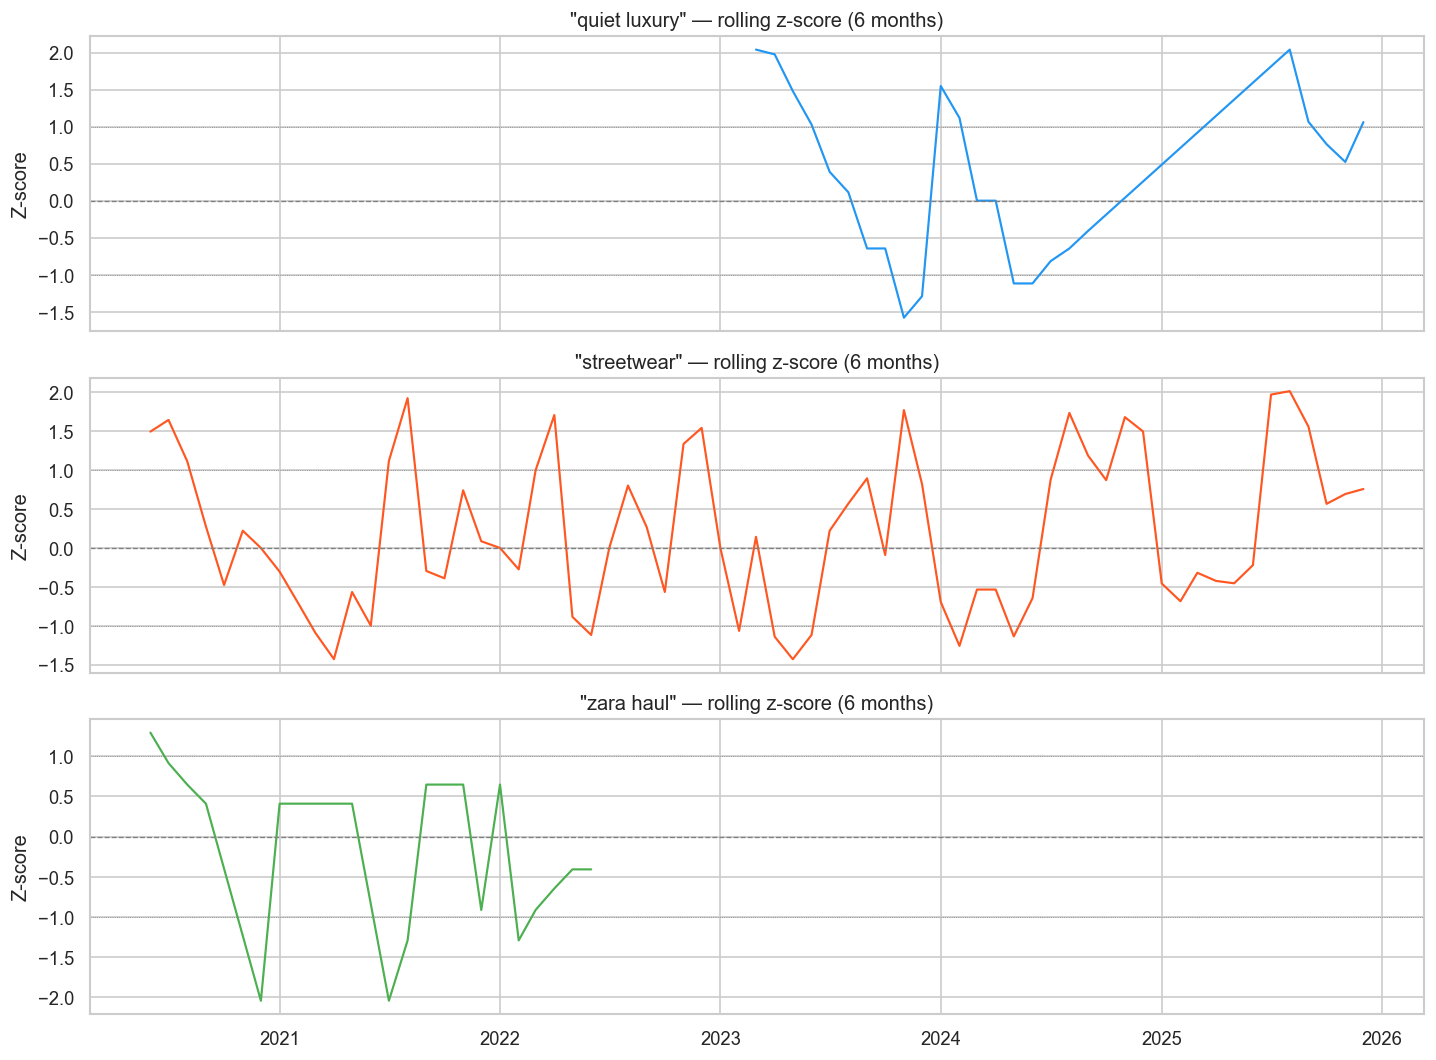

In [ ]:
# display rolling z score 
n_kw    = len(signals.columns)
colors  = ['#2196F3', '#FF5722', '#4CAF50']
fig, axes = plt.subplots(n_kw, 1, figsize=(12, 3 * n_kw), sharex=True)
if n_kw == 1:
    axes = [axes]

for ax, col, color in zip(axes, signals.columns, colors):
    s = signals[col].dropna()
    ax.plot(s.index, s, color=color, linewidth=1.3)
    ax.axhline(0,  color='grey', linewidth=0.8, linestyle='--')
    ax.axhline(1,  color='grey', linewidth=0.5, linestyle=':')
    ax.axhline(-1, color='grey', linewidth=0.5, linestyle=':')
    ax.set_ylabel('Z-score')
    ax.set_title(f'"{col}" — rolling z-score ({WINDOW} {FREQ_LABEL})')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()

plt.show()